In [1]:
import json, os
from collections import Counter
import numpy as np
from tqdm import tqdm
from scipy import stats

In [ ]:
files = os.listdir("/scratch/lamdo/IRB/runs/22March2026/step2_1")
all_lengths =[]
for file in tqdm(files):
    with open(os.path.join("/scratch/lamdo/IRB/runs/22March2026/step2_1", file)) as f:
        data = json.load(f)

    url_content_mapper = data.get("url_content_mapper")

    for k, v in url_content_mapper.items():
        if not v.get("accessible"): continue

        length = len(v.get("url_content"))
        all_lengths.append(length)

100%|██████████| 1224/1224 [00:00<00:00, 3769.91it/s]


In [11]:
np.median(all_lengths)

np.float64(3092.5)

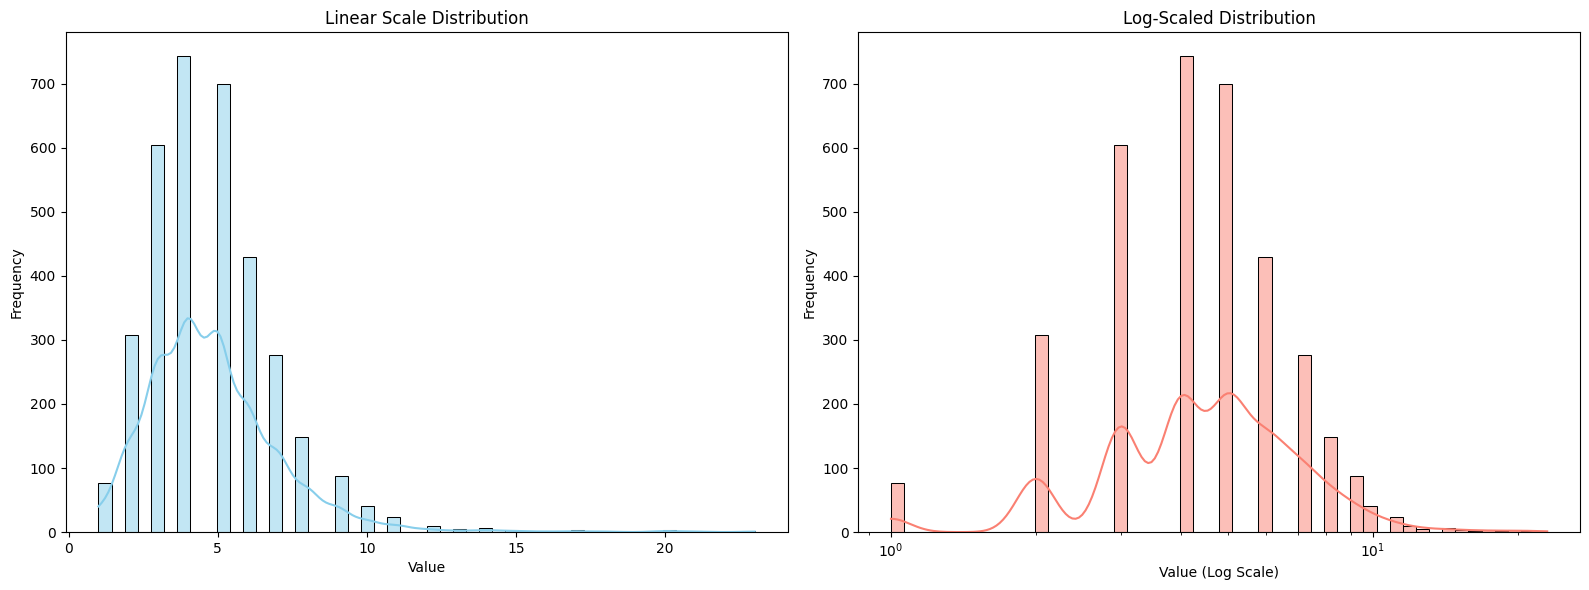

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Replace this with your actual list of integers
# Example: my_data = [123456, 789012, ...]
my_data = num_rels

# Create a figure with two subplots: Linear and Log Scale
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Standard Histogram (Linear Scale)
sns.histplot(my_data, bins=50, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Linear Scale Distribution')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# 2. Log-Scaled Histogram (Best for "Large Numbers" spanning orders of magnitude)
# log_scale=True automatically handles the axis transformation
sns.histplot(my_data, bins=50, kde=True, color='salmon', log_scale=True, ax=axes[1])
axes[1].set_title('Log-Scaled Distribution')
axes[1].set_xlabel('Value (Log Scale)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [2]:
extracted_kg_folder = "/scratch/lamdo/IRB/runs/22March2026/step4_extracted_kg"

files = os.listdir(extracted_kg_folder)

type_and_values = {}
num_rels = []
kg_count = 0
for file in files:
    file_full_path = os.path.join(extracted_kg_folder, file)

    with open(file_full_path) as f:
        data = json.load(f)

    fact_kg_mapper = data.get("fact_kg_mapper")
    if not fact_kg_mapper: continue

    for fact_id, kg in fact_kg_mapper.items():
        if not isinstance(kg, list): 
            print("oh no")
            continue
            
        num_rels.append(len(kg))
        kg_count += 1
        for triplet in kg:
            try:
                head = triplet["head"]
                head_type = triplet["head_type"]
                tail = triplet["tail"]
                tail_type = triplet["tail_type"]
            except KeyError: continue

            if head_type not in type_and_values: type_and_values[head_type] = []
            if tail_type not in type_and_values: type_and_values[tail_type] = []

            type_and_values[head_type].append(head)
            type_and_values[tail_type].append(tail)

In [4]:
kg_count, np.mean(num_rels)

(3477, np.float64(4.817946505608283))

In [7]:
type_counter = Counter()
for k,v in type_and_values.items():
    type_counter[k] = len(set(v))

type_counter.most_common(100)

[('Person', 18332),
 ('Event', 15087),
 ('Organization', 6672),
 ('Location', 6496),
 ('Group', 3678),
 ('Date', 3620),
 ('Occupation', 2321),
 ('Position', 2028),
 ('Description', 1713),
 ('Place', 1505),
 ('Tournament', 1494),
 ('Soccer team', 1422),
 ('Sports team', 1407),
 ('Concept', 1400),
 ('Action', 1373),
 ('Company', 1161),
 ('Title', 1124),
 ('Statement', 1092),
 ('Song', 1042),
 ('Time period', 1020),
 ('Film', 957),
 ('Activity', 801),
 ('Statistic', 734),
 ('Award', 725),
 ('City', 718),
 ('Time', 657),
 ('Character', 612),
 ('Sports event', 600),
 ('Quote', 552),
 ('Role', 540),
 ('Region', 534),
 ('Political party', 526),
 ('Publication', 507),
 ('Condition', 503),
 ('Object', 471),
 ('Album', 435),
 ('Achievement', 428),
 ('Document', 399),
 ('Quantity', 396),
 ('Duration', 372),
 ('Issue', 372),
 ('Entity', 363),
 ('Genre', 357),
 ('Reason', 350),
 ('Topic', 347),
 ('Purpose', 339),
 ('Persons', 334),
 ('Number', 333),
 ('Score', 332),
 ('Claim', 325),
 ('Election', 3

In [20]:
type_and_values["Statistic"]

['.314',
 '68 yards',
 '238 yards',
 '170 yards',
 '19 carries',
 '448 passing yards',
 '2,176 yards',
 '57 sacks',
 '86 yards',
 'two touchdowns',
 '54',
 '684 yards',
 'two penalty kicks',
 '23 yellow cards',
 '63 century breaks',
 '16 tackles',
 'two fumble recoveries',
 'Approval rating among Japanese women aged 18 to 29',
 '5 rebounds',
 'nine assists',
 '26 points',
 '4.5 rebounds',
 '1.0 blocked shots',
 '4.0 assists',
 '2.0 steals',
 '16 minutes per game',
 '146 yards',
 'four passes',
 'death toll in the Rasht massacre',
 '10.6 points',
 '16% having cut off contact with one or both parents',
 '38% estranged from a close relative',
 '38% of the American population is estranged from a close relative',
 '16% of the American population have cut off contact with one or both parents',
 '28% of Generation Z individuals',
 '66% of the respondents']

In [7]:
import humanize

humanize.intword(int("280000"))

'280.0 thousand'

In [9]:
import requests

def get_wikipedia_json_batch(titles):
    email = os.environ.get("MY_EMAIL")
    headers = {
        'User-Agent': f'IRB/1.0 ({email})'
    }

    URL = "https://en.wikipedia.org/w/api.php"
    
    # Join titles with the pipe character '|'
    params = {
        "action": "query",
        "format": "json",
        "titles": "|".join(titles),
        "prop": "cirrusdoc"
    }
    
    response = requests.get(URL, params=params, headers=headers)
    response.raise_for_status()
    
    data = response.json()
    pages = data.get('query', {}).get('pages', {})
    
    # Create a mapping of title -> page data
    results = {}
    for page_id, content in pages.items():
        title = content.get('title')
        # If page_id is negative, the page doesn't exist
        results[title] = content if int(page_id) > 0 else None
        
    return results

In [14]:
test = get_wikipedia_json_batch(["Indonesia Air Transport"])

In [15]:
test

{'Indonesia Air Transport': {'pageid': 1632533,
  'ns': 0,
  'title': 'Indonesia Air Transport',
  'cirrusdoc': [{'index': 'enwiki_content_1764769142',
    'type': '_doc',
    'id': '1632533',
    'version': [],
    'source': {'template': ['Template:Short description',
      'Template:Pagetype',
      'Template:Main other',
      'Template:Short description/lowercasecheck',
      'Template:SDcat',
      'Template:Infobox airline',
      'Template:If empty',
      'Template:Start date and age',
      'Template:Yesno',
      'Template:Years or months ago',
      'Template:URL',
      'Template:Infobox airline/styles.css',
      'Template:Infobox/mobileviewfix.css',
      'Template:Idx',
      'Template:Indonesia Stock Exchange',
      'Template:Terminated',
      'Template:Airline hub',
      'Template:Citations needed',
      'Template:More citations needed',
      'Template:Ambox',
      'Template:Find sources mainspace',
      'Template:Reflist',
      'Template:Reflist/styles.css',
 

In [ ]:
import pyproj
from geopy.distance import geodesic

def get_compass_direction(bearing):
    """Converts a 0-360 degree bearing into a 16-point compass direction."""
    directions = [
        "North", "North-Northeast", "Northeast", "East-Northeast", "East",
        "East-Southeast", "Southeast", "South-Southeast", "South",
        "South-Southwest", "Southwest", "West-Southwest", "West",
        "West-Northwest", "Northwest", "North-Northwest"
    ]
    
    # Divide the 360 degrees into 16 sectors of 22.5 degrees each.
    # We round the division to shift the sectors so 'North' covers 348.75 to 11.25.
    index = round(bearing / 22.5) % 16
    return directions[index]

def generate_directional_distance_trivia(random_location, target):
    lat1, lon1, city1, type1 = random_location["lat"], random_location["long"], random_location["name"], random_location["type"]
    lat2, lon2, city2, type2 = target["lat"], target["long"], target["name"], target["type"]

    coords1 = (lat1, lon1)
    coords2 = (lat2, lon2)

    distance_miles = geodesic(coords1, coords2).miles
    
    geod = pyproj.Geod(ellps='WGS84')
    fwd_azimuth, back_azimuth, _ = geod.inv(lon1, lat1, lon2, lat2)
    
    compass_bearing = (fwd_azimuth + 360) % 360
    
    readable_direction = get_compass_direction(compass_bearing)
    
    res = f"""The {type2} that is {int(distance_miles):,} miles, {readable_direction} ({compass_bearing:.1f}°) of {type1} of {city1}"""

    return res

# Example: Urbana, IL to Hanoi, Vietnam

inp1 = {
        "name": "Somali",
        "type": "region",
        "lat": 7.2629844,
        "long": 43.5360531
    }
target = {
        "name": "Illinois",
        "type": "state",
        "lat": 40.0796606,
        "long": -89.4337288
    }
generate_directional_distance_trivia(inp1, target)

'The state that is 8,012 miles, Northwest (321.6°) of region of Somali'